# ***INSTALL DEPENDENCIES*** #

In [215]:
import os
import os.path as op
import tarfile
import shutil
from zipfile import ZipFile
from urllib.request import urlretrieve
from IPython.display import Markdown, display


def create_folder(folder):
    if not op.exists(folder):
        os.mkdir(folder)
        print(f"Creating:\t\t {folder}")
    else:
        print(f"Already exist:\t\t {folder}")

def download_file(url, filename):
    if not op.exists(filename):
        print(f"Downloading:\t {url} --> {filename}")
        urlretrieve(url, filename)
    else:
        print(f"Already downloaded:\t {url} --> {filename}")
        
def download_folder(url, foldername_src, foldername):
    if not op.exists(foldername):
        print(f"Cloning:\t\t {foldername_src} --> {foldername}")
        os.system(f"git clone --quiet --depth 1 {url} temp_repo")
        shutil.move(op.join("temp_repo", foldername_src), foldername)
        shutil.rmtree("temp_repo")
    else:
        print(f"Already downloaded:\t {foldername}")

def extract_file(main, filename, foldername):
    if not op.exists(foldername):
        print(f'Extracting:\t\t {filename} --> {foldername}')
        file_extension = os.path.splitext(filename)[1].lower()
        if file_extension == '.zip':
            with ZipFile(filename, 'r') as zip_ref:
                zip_ref.extractall(main)
        elif file_extension in ('.tar', '.gz', '.bz2', '.xz'):
            with tarfile.open(filename, 'r:*') as tar_ref:
                tar_ref.extractall(path=main)
        else:
            print(f"Unsupported file type: {file_extension}")
    else:
        print(f'Already extracted:\t {filename} --> {foldername}')


DOWNLOADS = "Downloads"
FILES = "Files"
SIAMESE_URL = "https://raw.githubusercontent.com/KeremDUZENLI/python-keras-deep-learning/main/notebooks/Files/siamese.svg"
SIAMESE_FILE = FILES + "/siamese.svg"
SIAMESE_PRE_URL = "https://raw.githubusercontent.com/KeremDUZENLI/python-keras-deep-learning/main/notebooks/Files/siamese_pretrained.h5"
SIAMESE_PRE_FILE = FILES + "/siamese_pretrained.h5"
TRIPLET_PRE_URL = "https://raw.githubusercontent.com/KeremDUZENLI/python-keras-deep-learning/main/notebooks/Files/triplet_pretrained.h5"
TRIPLET_PRE_FILE = FILES + "/triplet_pretrained.h5"
TEST_IMAGES_URL = "https://github.com/KeremDUZENLI/python-jupyter-deep-learning.git"
TEST_IMAGES_FOLDER_SRC = "notebooks/Files/test_images"
TEST_IMAGES_FOLDER = FILES + "/test_images"

with open('../README.md', 'r', encoding='utf-8') as f:
    display(Markdown(f.read()))
create_folder(DOWNLOADS)
create_folder(FILES)
download_file(SIAMESE_URL, SIAMESE_FILE)
download_file(SIAMESE_PRE_URL, SIAMESE_PRE_FILE)
download_file(TRIPLET_PRE_URL, TRIPLET_PRE_FILE)
download_folder(TEST_IMAGES_URL, TEST_IMAGES_FOLDER_SRC, TEST_IMAGES_FOLDER)


# KAGGLE
def download_kaggle_dataset(dataset_id, foldername, filename):
    if not op.exists(filename):
        print(f"Kaggle:\t\t\t {dataset_id} --> {foldername}")
        os.system(f"kaggle datasets download -d {dataset_id} -p {foldername}")
    else:
        print(f"Already downloaded:\t Kaggle API --> {filename}")

def fix_nested_extraction(main, foldername_inner):
    nested_folder = op.join(main, foldername_inner)
    if op.exists(nested_folder):
        print(f"Fixing nested:\t {nested_folder} --> {main}")
        for item in os.listdir(nested_folder):
            shutil.move(op.join(nested_folder, item), main)
        os.rmdir(nested_folder)


KAGGLE_DATASET_ID = "jessicali9530/lfw-dataset"
KAGGLE_ZIP = op.join(DOWNLOADS, "lfw-dataset.zip")
LFW_FOLDER = op.join(DOWNLOADS, "lfw-deepfunneled")
LFW_FOLDER_INNER = "lfw-deepfunneled"

download_kaggle_dataset(KAGGLE_DATASET_ID, DOWNLOADS, KAGGLE_ZIP)
extract_file(DOWNLOADS, KAGGLE_ZIP, LFW_FOLDER)
fix_nested_extraction(LFW_FOLDER, LFW_FOLDER_INNER)

# Deep Learning Examples with Keras

A collection of deep learning examples using Keras, covering neural networks, recommender systems, convolutions, and object detection. Based on the course **Advanced Machine Learning**, University of Debrecen.

## Project Directory (Colab Version)

You can access the Colab version of the project directly on Link:

[drive.google.com/drive/folders/1gJqkJh2jvNHUSmyQp5vk0GiSGvVwJtlP](https://drive.google.com/drive/folders/1gJqkJh2jvNHUSmyQp5vk0GiSGvVwJtlP)

## Project Directory (Standalone Version)

You can access the non-Colab version of the project directly on GitHub:

[github.com/KeremDUZENLI/python-jupyter-deep-learning](https://github.com/KeremDUZENLI/python-jupyter-deep-learning)

## Install

1. Download Python 3.6.8: [Python 3.6.8 Download](https://www.python.org/downloads/release/python-368/)
2. Check Python versions installed: `py -0`
3. Check the default version: `python --version`
4. Check python locations: `where python`
5. Verify python 3.6.x location: `...\AppData\Local\Programs\Python\Python36\python.exe`

## Setup

1. Clone the repository:
   ```sh
   git clone https://github.com/KeremDUZENLI/python-jupyter-deep-learning.git
   ```
2. Create a virtual environment:
   ```sh
   ...\AppData\Local\Programs\Python\Python36\python.exe -m venv myEnv
   ```
3. Activate the virtual environment:
   - **Windows**: `myEnv\Scripts\activate`
   - **Linux/macOS**: `source myEnv/bin/activate`
4. Update pip:
   ```sh
   python -m pip install --upgrade pip
   ```
5. Update setuptools:
   ```sh
   pip install --upgrade setuptools
   ```
6. Install dependencies:
   ```sh
   pip install -r requirements.txt
   ```
7. Freeze dependencies (optional):
   ```sh
   python -m pip freeze > requirements.txt
   ```

## Notebooks

1. Install Jupyter:
   ```sh
   pip install jupyterlab
   ```
2. Register Python Environment:
   ```sh
   pip install jupyterlab ipykernel
   python -m ipykernel install --user --name=env_deep_learning --display-name "Python 3.6.8 (Deep Learning)"
   ```
3. Launch Jupyter:
   ```sh
   jupyter lab
   ```
4. Change Kernel:
   ```sh
   Change kernel in Jupyterlab (Select after choosing the .ipynb file) =
   Kernel → Change Kernel → Python (myEnv)
   ```

## Quick Run (after installation)

1. Activate the virtual environment:
   - **Windows**: `myEnv\Scripts\activate`
   - **Linux/macOS**: `source myEnv/bin/activate`
2. Launch Jupyter:
   ```sh
   jupyter lab
   ```
3. Change Kernel (if needed):
   ```sh
   Change kernel in Jupyterlab (Select after choosing the .ipynb file) =
   Kernel → Change Kernel → Python (myEnv)
   ```

### Notebook Descriptions

- [1. Neural Networks](notebooks/1_neural_networks.ipynb) – Basics of neural networks with Keras.
- [2. Backpropagation](notebooks/2_backpropagation.ipynb) – Understanding the backpropagation algorithm and its implementation in Keras.
- [3. Neural Recommender](notebooks/3_neural_recommender.ipynb) – Building a simple recommender system using neural networks.
- [4. Convolutional Networks](notebooks/4_convolutional_network.ipynb) – Introduction to convolutional neural networks (CNNs) for image classification.
- [5. Fully Convolutional Networks](notebooks/5_full_convolutional_network.ipynb) – Implementing a full convolutional network for image segmentation tasks.
- [6. CNN Classification](notebooks/6_convolutional_network_classification.ipynb) – Classifying images using a convolutional neural network.
- [7. Text Classification & Seq2Seq Translation](notebooks/7_text_classification_seq2seq_translation.ipynb) – Text classification using RNNs and sequence-to-sequence models for language translation.
- [8. Variational Autoencoders](notebooks/8_variational_autoencoders.ipynb) – Implementing variational autoencoders for generative modeling.
- [9 Face Verification](9_face_verification.ipynb) – Face Verification

## Acknowledgments

This project is based on the **Advanced Machine Learning** course at the **University of Debrecen**

- **Prof. Dr. András Hajdu** – Dean, Head of Department
  - _Department of Data Science and Visualization, Faculty of Informatics, University of Debrecen_
  - Email: [hajdu.andras@inf.unideb.hu](mailto:hajdu.andras@inf.unideb.hu)

- **Dr. Balázs Harangi** – Associate Professor, Deputy Head of Department
  - _Department of Data Science and Visualization, Faculty of Informatics, University of Debrecen_
  - Email: [harangi.balazs@inf.unideb.hu](mailto:harangi.balazs@inf.unideb.hu)

- **Kerem Düzenli** – PhD Candidate, University of Debrecen
  - _Creator and maintainer of this repository_
  - Email: [kerem.duzenli@inf.unideb.hu](mailto:kerem.duzenli@inf.unideb.hu)

## Contributing

1. Fork the repository.
2. Create a new branch:
   ```sh
   git checkout -b YourBranch
   ```
3. Make your changes and commit them:
   ```sh
   git commit -m "Add some feature"
   ```
4. Push to the branch:
   ```sh
   git push origin YourBranch
   ```
5. Open a pull request.

## License

This project is licensed under the **Creative Commons Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)** license. This means you are free to:

- **Share** – Copy and redistribute the material in any medium or format.
- **Adapt** – Remix, transform, and build upon the material.

However, **you may not use the material for commercial purposes**.

For details, see the [LICENSE](LICENSE) file or read more at [Creative Commons](https://creativecommons.org/licenses/by-nc/4.0/).

## Disclaimer

This repository is intended **only for educational and research purposes**. The authors and contributors assume no responsibility for misuse of the code or any implications arising from its use.

## Support My Work

If you find this resource valuable and would like to help support my education and doctoral research, please consider treating me to a cup of coffee (or tea) via Revolut.

<div align="center">
  <a href="https://revolut.me/krmdznl" target="_blank">
    <img src="https://img.shields.io/badge/Support%20My%20Projects-Donate%20via%20Revolut-orange?style=for-the-badge" alt="Support my education via Revolut" />
  </a>
</div> <br>


Already exist:		 Downloads
Already exist:		 Files
Already downloaded:	 https://raw.githubusercontent.com/KeremDUZENLI/python-keras-deep-learning/main/notebooks/Files/siamese.svg --> Files/siamese.svg
Already downloaded:	 https://raw.githubusercontent.com/KeremDUZENLI/python-keras-deep-learning/main/notebooks/Files/siamese_pretrained.h5 --> Files/siamese_pretrained.h5
Already downloaded:	 https://raw.githubusercontent.com/KeremDUZENLI/python-keras-deep-learning/main/notebooks/Files/triplet_pretrained.h5 --> Files/triplet_pretrained.h5
Already downloaded:	 Files/test_images
Kaggle:			 jessicali9530/lfw-dataset --> Downloads
Already extracted:	 Downloads\lfw-dataset.zip --> Downloads\lfw-deepfunneled


# **PART I: Face Verification Using Siamese Networks** #

# Step 0: Imports & Config

In [145]:
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2

import keras
import keras.backend as K
from keras import optimizers
from keras.models import Model, load_model
from keras.layers import Dense, Input, Concatenate, merge, Lambda, Dot
from keras.layers import Conv2D, MaxPool2D, GlobalAveragePooling2D, Flatten, Dropout
from keras.callbacks import ModelCheckpoint
from keras.backend.tensorflow_backend import set_session

from skimage.io import imread
from skimage.transform import resize
from sklearn.manifold import TSNE

from imgaug import augmenters as iaa


config = tf.ConfigProto()
config.gpu_options.per_process_gpu_memory_fraction = 0.7
set_session(tf.Session(config=config))

# Step 1: Applying a Simple Convolution

In [146]:
dirs = sorted([d for d in os.listdir(LFW_FOLDER) if op.isdir(op.join(LFW_FOLDER, d))])
dirs = dirs[:500]

name_to_classid = {d: i for i, d in enumerate(dirs)}
classid_to_name = {v: k for k, v in name_to_classid.items()}

num_classes = len(name_to_classid)
print("number of classes: ", num_classes)

number of classes:  500


In [147]:
img_paths = {c: [op.join(LFW_FOLDER, subfolder, img) 
                 for img in sorted(os.listdir(op.join(LFW_FOLDER, subfolder)))] 
             for subfolder, c in name_to_classid.items()}

all_images_path = []
for img_list in img_paths.values():
    all_images_path += img_list

path_to_id = {v: k for k, v in enumerate(all_images_path)}
id_to_path = {v: k for k, v in path_to_id.items()}

classid_to_ids = {k: [path_to_id[path] for path in v] for k, v in img_paths.items()}
id_to_classid = {v: c for c,imgs in classid_to_ids.items() for v in imgs}
dict(list(id_to_classid.items())[0:13])

{0: 0,
 1: 1,
 2: 2,
 3: 3,
 4: 4,
 5: 5,
 6: 5,
 7: 5,
 8: 5,
 9: 6,
 10: 7,
 11: 7,
 12: 8}

In [148]:
[(classid_to_name[x], len(classid_to_ids[x]))
 for x in np.argsort([len(v) for k,v in classid_to_ids.items()])[::-1][:10]]

[('Ariel_Sharon', 77),
 ('Arnold_Schwarzenegger', 42),
 ('Alejandro_Toledo', 39),
 ('Andre_Agassi', 36),
 ('Alvaro_Uribe', 35),
 ('Atal_Bihari_Vajpayee', 24),
 ('Amelie_Mauresmo', 21),
 ('Angelina_Jolie', 20),
 ('Abdullah_Gul', 19),
 ('Andy_Roddick', 15)]

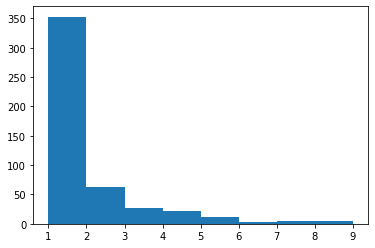

In [149]:
plt.hist([len(v) for k,v in classid_to_ids.items()], bins=range(1,10))
plt.show()

# Step 2: Siamese Networks

A siamese net takes as input two images $x_1$ and $x_2$ and outputs a single value which corresponds to the similarity between $x_1$ and $x_2$, as follows:

<img src="Files/siamese.svg" style="width: 600px;" />

In order to train such a system, one has to build positive and negative pairs for the training.

In [150]:
def build_pos_pairs_for_id(classid, max_num=50):
    imgs = classid_to_ids[classid]
    if len(imgs) == 1:
        return []
    pos_pairs = [(imgs[i], imgs[j])
                 for i in range(len(imgs))
                 for j in range(i + 1, len(imgs))]
    random.shuffle(pos_pairs)
    return pos_pairs[:max_num]


def build_neg_pairs_for_id(classid, classes, max_num=20):
    imgs = classid_to_ids[classid]
    neg_classes_ids = random.sample(classes, max_num+1)
    if classid in neg_classes_ids:
        neg_classes_ids.remove(classid)
    neg_pairs = []
    for id2 in range(max_num):
        img1 = imgs[random.randint(0,len(imgs)-1)]
        imgs2 = classid_to_ids[neg_classes_ids[id2]]
        img2 = imgs2[random.randint(0,len(imgs2)-1)]
        neg_pairs += [(img1, img2)]
    return neg_pairs

In [151]:
build_pos_pairs_for_id(5, 20)

[(6, 7), (5, 6), (6, 8), (5, 7), (7, 8), (5, 8)]

In [152]:
build_neg_pairs_for_id(5, list(range(num_classes)), 6)

[(5, 605), (7, 616), (5, 745), (6, 1116), (5, 391), (6, 67)]

Now that we have a way to compute the pairs, let's open all the possible images. It will expand all the images into RAM memory. There are more than 1000 images, so 100Mo of RAM will be used, which will not cause any issue.

In [153]:
def resize100(img):
    return resize(img, (100, 100), preserve_range=True, mode='reflect')[20:80,20:80,:]


def open_all_images(id_to_path):
    all_imgs = []
    for path in id_to_path.values():
        all_imgs += [np.expand_dims(resize100(imread(path)),0)]
    return np.vstack(all_imgs)

In [154]:
all_imgs = open_all_images(id_to_path)
all_imgs.shape

(1155, 60, 60, 3)

In [155]:
str(all_imgs.nbytes / 1e6) + "MB"

'99.792MB'

In [156]:
def build_train_test_data(split=0.8):
    listX1 = []
    listX2 = []
    listY = []
    split = int(num_classes * split)
    
    # train
    for id in range(split):
        pos = build_pos_pairs_for_id(id)
        neg = build_neg_pairs_for_id(id, list(range(split)))
        for pair in pos:
            listX1 += [pair[0]]
            listX2 += [pair[1]]
            listY += [1]
        for pair in neg:
            if sum(listY) > len(listY) / 2:
                listX1 += [pair[0]]
                listX2 += [pair[1]]
                listY += [0]
    perm = np.random.permutation(len(listX1))
    X1_ids_train = np.array(listX1)[perm]
    X2_ids_train = np.array(listX2)[perm]
    Y_ids_train = np.array(listY)[perm]
    
    listX1 = []
    listX2 = []
    listY = []
    
    #test
    for id in range(split, num_classes):
        pos = build_pos_pairs_for_id(id)
        neg = build_neg_pairs_for_id(id, list(range(split, num_classes)))
        for pair in pos:
            listX1 += [pair[0]]
            listX2 += [pair[1]]
            listY += [1]
        for pair in neg:
            if sum(listY) > len(listY) / 2:
                listX1 += [pair[0]]
                listX2 += [pair[1]]
                listY += [0]
    X1_ids_test = np.array(listX1)
    X2_ids_test = np.array(listX2)
    Y_ids_test = np.array(listY)
    return (X1_ids_train, X2_ids_train, Y_ids_train,
            X1_ids_test, X2_ids_test, Y_ids_test)

In [157]:
X1_ids_train, X2_ids_train, train_Y, X1_ids_test, X2_ids_test, test_Y = build_train_test_data()

X1_ids_train.shape, X2_ids_train.shape, train_Y.shape

((2354,), (2354,), (2354,))

In [158]:
np.mean(train_Y)

0.5

In [159]:
X1_ids_test.shape, X2_ids_test.shape, test_Y.shape

((298,), (298,), (298,))

In [160]:
np.mean(test_Y)

0.5

# Step 3: Data Augmentation and Generator

In [161]:
# horizontally flip 50% of the images
seq = iaa.Sequential([iaa.Fliplr(0.5)])

In [162]:
class Generator:

    def __init__(self, X1, X2, Y, batch_size, all_imgs):
        self.cur_train_index=0
        self.batch_size = batch_size
        self.X1 = X1
        self.X2 = X2
        self.Y = Y
        self.imgs = all_imgs
        self.num_samples = Y.shape[0]
        
    def next_train(self):
        while 1:
            self.cur_train_index += self.batch_size
            if self.cur_train_index >= self.num_samples:
                self.cur_train_index=0
            
            imgs1 = self.X1[self.cur_train_index:self.cur_train_index+self.batch_size]
            imgs2 = self.X2[self.cur_train_index:self.cur_train_index+self.batch_size]
      
            yield ([seq.augment_images(self.imgs[imgs1]), 
                    seq.augment_images(self.imgs[imgs2])],
                   self.Y[self.cur_train_index:self.cur_train_index+self.batch_size])

In [163]:
gen = Generator(X1_ids_train, X2_ids_train, train_Y, 32, all_imgs)
[x1, x2], y = next(gen.next_train())

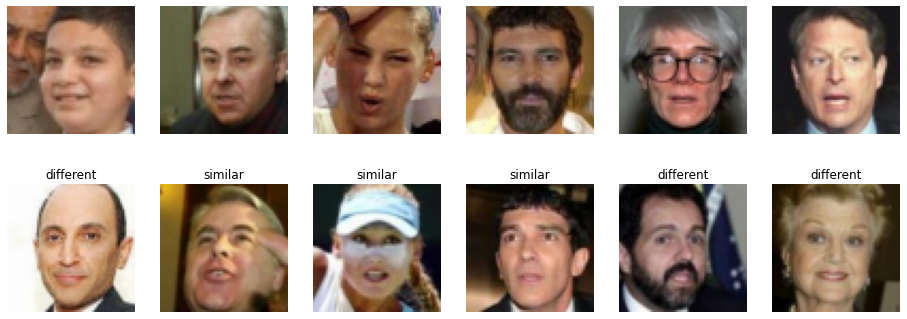

In [164]:
plt.figure(figsize=(16, 6))

for i in range(6):
    plt.subplot(2, 6, i + 1)
    plt.imshow(x1[i] / 255)
    plt.axis('off')
for i in range(6):
    plt.subplot(2, 6, i + 7)
    plt.imshow(x2[i] / 255)
    if y[i]==1.0:
        plt.title("similar")
    else:
        plt.title("different")
    plt.axis('off')

plt.show()

**Exercise**

- Add your own dataaugmentations in the process. You may look at: http://imgaug.readthedocs.io for instance use `iaa.Affine`;
- Be careful not to make the task to difficult, and to add meaningful augmentations;
- Rerun the generator plot above to check whether the image pairs look not too distorted to recognize the identities.

**Test images**

- In addition to our generator, we need test images, unaffected by the augmentation


In [165]:
test_X1 = all_imgs[X1_ids_test]
test_X2 = all_imgs[X2_ids_test]

test_X1.shape, test_X2.shape, test_Y.shape

((298, 60, 60, 3), (298, 60, 60, 3), (298,))

# Step 4: Simple Convolutional Model

In [166]:
def contrastive_loss(y_true, y_pred, margin=0.25):
    '''Contrastive loss from Hadsell-et-al.'06
    http://yann.lecun.com/exdb/publis/pdf/hadsell-chopra-lecun-06.pdf
    '''
    return K.mean( y_true * K.square(1 - y_pred) +
                  (1 - y_true) * K.square(K.maximum(y_pred - margin, 0)))


def accuracy_sim(y_true, y_pred, threshold=0.5):
    '''Compute classification accuracy with a fixed threshold on similarity.
    '''
    y_thresholded = K.cast(y_pred > threshold, y_true.dtype)
    return K.mean(K.equal(y_true, y_thresholded))

**Exercise**

- Build a convolutional model which transforms the input to a fixed dimension $d = 50$
- You may alternate convolutions and maxpooling and layers,
- Use the relu activation on convolutional layers,
- At the end, `Flatten` the last convolutional output and plug it into a dense layer.
- Feel free to use some `Dropout` prior to the Dense layer.

Use between 32 and 128 channels on convolutional layers. Be careful: large convolutions on high dimensional images can be very slow on CPUs.

Try to run your randomly initialized `shared_conv` model on a batch of the first 10 images from `all_imgs`. What is the expected shape of the output?


In [167]:
inp = Input((60, 60, 3), dtype='float32')
x = inp
shared_conv = Model(inputs=inp, outputs=x)

In [168]:
inp = Input((60, 60, 3), dtype='float32')

x = Conv2D(16, 3, activation="relu", padding="same")(inp)
x = Conv2D(16, 3, activation="relu", padding="same")(x)
x = MaxPool2D((2,2))(x) # 30,30
x = Conv2D(32, 3, activation="relu", padding="same")(x)
x = Conv2D(32, 3, activation="relu", padding="same")(x)
x = MaxPool2D((2,2))(x) # 15,15
x = Conv2D(64, 3, activation="relu", padding="same")(x)
x = Conv2D(64, 3, activation="relu", padding="same")(x)
x = MaxPool2D((2,2))(x) # 8,8
x = Conv2D(64, 3, activation="relu", padding="same")(x)
x = Conv2D(32, 3, activation="relu", padding="same")(x)
x = Flatten()(x)
x = Dropout(0.2)(x)
x = Dense(50)(x)

shared_conv = Model(inputs=inp, outputs=x)

all_imgs.shape

(1155, 60, 60, 3)

In [169]:
shared_conv.predict(all_imgs[:10]).shape

(10, 50)

In [170]:
shared_conv.summary()

Model: "model_23"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_19 (InputLayer)        (None, 60, 60, 3)         0         
_________________________________________________________________
conv2d_41 (Conv2D)           (None, 60, 60, 16)        448       
_________________________________________________________________
conv2d_42 (Conv2D)           (None, 60, 60, 16)        2320      
_________________________________________________________________
max_pooling2d_16 (MaxPooling (None, 30, 30, 16)        0         
_________________________________________________________________
conv2d_43 (Conv2D)           (None, 30, 30, 32)        4640      
_________________________________________________________________
conv2d_44 (Conv2D)           (None, 30, 30, 32)        9248      
_________________________________________________________________
max_pooling2d_17 (MaxPooling (None, 15, 15, 32)        0  

# Step 5: Assemble the Siamese Model

**Exercise**

Assemble the siamese model by combining:

- `shared_conv` on both inputs;
- compute the cosine similarity using the [Dot](https://keras.io/layers/merge/#dot) layer with `normalize=True` on the outputs of the two `shared_conv` instance lanes;
- the loss of siamese model is the constrastive loss defined previously;
- use the `accuracy_sim` function defined previously as a metric.


In [171]:
i1 = Input((60, 60, 3), dtype='float32')
i2 = Input((60, 60, 3), dtype='float32')

x1 = shared_conv(i1)
x2 = shared_conv(i2)

out = Dot(axes=-1, normalize=True)([x1, x2])
model = Model(inputs=[i1, i2], outputs=out)

model.compile(loss=contrastive_loss, optimizer='rmsprop', metrics=[accuracy_sim])
model.summary()

Model: "model_24"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_20 (InputLayer)           (None, 60, 60, 3)    0                                            
__________________________________________________________________________________________________
input_21 (InputLayer)           (None, 60, 60, 3)    0                                            
__________________________________________________________________________________________________
model_23 (Model)                (None, 50)           205922      input_20[0][0]                   
                                                                 input_21[0][0]                   
__________________________________________________________________________________________________
dot_20 (Dot)                    (None, 1)            0           model_23[1][0]            

In [172]:
i1 = Input((60, 60, 3), dtype='float32')
i2 = Input((60, 60, 3), dtype='float32')

x1 = shared_conv(i1)
x2 = shared_conv(i2)

out = Dot(axes=-1, normalize=True)([x1, x2])

model = Model(inputs=[i1, i2], outputs=out)
model.compile(loss=contrastive_loss, optimizer='rmsprop', metrics=[accuracy_sim])

out = Lambda(lambda x: K.abs(x[0] - x[1]))([x1, x2])
out = Dense(1, activation="sigmoid")(out)

model = Model(inputs=[i1, i2], outputs=out)
model.compile(loss="binary_crossentropy", optimizer="rmsprop", metrics=["accuracy"])

In [173]:
best_model_fname = "Files/siamese_checkpoint.h5"

best_model_cb = ModelCheckpoint(best_model_fname, 
                                monitor='val_accuracy',
                                save_best_only=True, 
                                verbose=1)

In [174]:
model.fit_generator(generator=gen.next_train(), 
                    steps_per_epoch=train_Y.shape[0] // 32, 
                    epochs=3,
                    validation_data=([test_X1, test_X2], test_Y),
                    callbacks=[best_model_cb], verbose=2)

Epoch 1/3
 - 17s - loss: 0.7587 - accuracy: 0.5013 - val_loss: 0.6942 - val_accuracy: 0.4899

Epoch 00001: val_accuracy improved from -inf to 0.48993, saving model to Files/siamese_checkpoint.h5
Epoch 2/3
 - 17s - loss: 0.7009 - accuracy: 0.5030 - val_loss: 0.6854 - val_accuracy: 0.5101

Epoch 00002: val_accuracy improved from 0.48993 to 0.51007, saving model to Files/siamese_checkpoint.h5
Epoch 3/3
 - 17s - loss: 0.7009 - accuracy: 0.4842 - val_loss: 0.6931 - val_accuracy: 0.5302

Epoch 00003: val_accuracy improved from 0.51007 to 0.53020, saving model to Files/siamese_checkpoint.h5


In [175]:
# model.load_weights("Files/siamese_checkpoint.h5", by_name=True)
model.load_weights(SIAMESE_PRE_FILE, by_name=True)

**Exercise**

Finding the most similar images

- Run the shared_conv model on all images;
- (Optional) add Charles and Olivier's faces from the `test_images` folder to the test set;
- build a `most_sim` function which returns the most similar vectors to a given vector.


In [176]:
more_img_paths = {
    'olivier': [os.path.join('Files/test_images/olivier', img)
                for img in sorted(os.listdir('Files/test_images/olivier'))],
    'charles': [os.path.join('Files/test_images/charles', img)
                for img in sorted(os.listdir('Files/test_images/charles'))],
}
img_paths.update(more_img_paths)

all_images_path = []
for img_list in img_paths.values():
    all_images_path += img_list

path_to_id = {v: k for k, v in enumerate(all_images_path)}
id_to_path = {v: k for k, v in path_to_id.items()}
all_imgs = open_all_images(id_to_path)

emb = shared_conv.predict(all_imgs)
emb = emb / np.linalg.norm(emb, axis=-1, keepdims=True)

# Step 6: Most Similar Faces

The following enables to display an image alongside with most similar images:

- The results are weak, first because of the size of the dataset
- Also, the network can be greatly improved


In [177]:
def most_sim(x, emb, topn=4):
    sims = np.dot(emb, x)
    ids = np.argsort(sims)[::-1]
    return [(id, sims[id]) for id in ids[:topn]]


def display(img):
    img = img.astype('uint8')
    plt.imshow(img)
    plt.axis('off')
    plt.show()

query: Ashanti 988


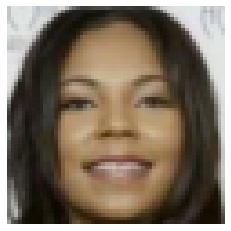

In [178]:
interesting_classes = list(filter(lambda x: len(x[1]) > 4, classid_to_ids.items()))
class_id = random.choice(interesting_classes)[0]

query_id = random.choice(classid_to_ids[class_id])
print("query:", classid_to_name[class_id], query_id)
display(all_imgs[query_id])

nearest matches
Ashanti 988 1.0


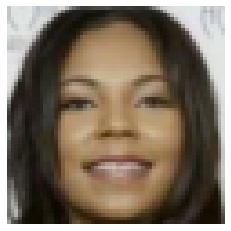

Ana_Isabel_Sanchez 511 0.9603716


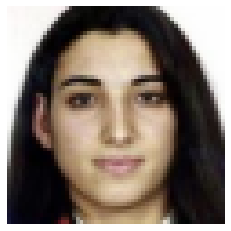

Barbra_Streisand 1074 0.9509926


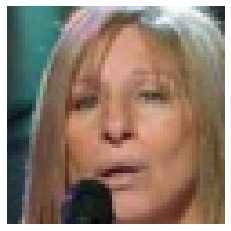

Ari_Fleischer 800 0.9450599


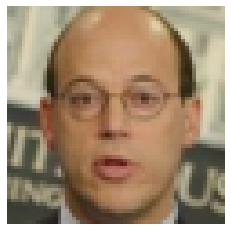

In [179]:
print("nearest matches")
for result_id, sim in most_sim(emb[query_id], emb):
    class_name = classid_to_name.get(id_to_classid.get(result_id))
    print(class_name, result_id, sim)    
    display(all_imgs[result_id])

Note that this model is still underfitting, even when running queries against the training set. Even if the results are not correct, the mistakes often seem to "make sense" though.

Running a model to convergence on higher resolution images, possibly with a deeper and wider convolutional network might yield better results. In the next notebook we will try with a better loss and with hard negative mining.


# Step 7: Playing with the Camera

In [180]:
def camera_grab(camera_id=0, fallback_filename=None):
    camera = cv2.VideoCapture(camera_id)
    
    try:
        for i in range(10):
            snapshot_ok, image = camera.read()
        if snapshot_ok:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        else:
            print("WARNING: could not access camera")
            if fallback_filename:
                image = imread(fallback_filename)
    finally:
        camera.release()

    return image

query image:


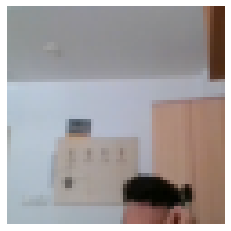

Aitor_Gonzalez 146 0.46236143


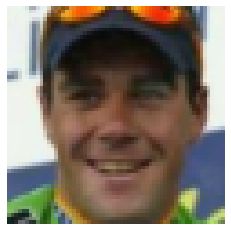

None 1155 0.46093094


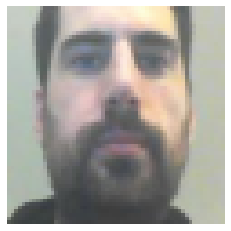

Ambrose_Lee 458 0.4606697


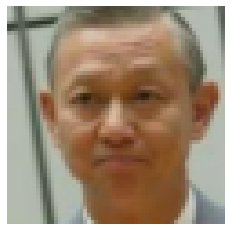

Ascencion_Barajas 984 0.45844364


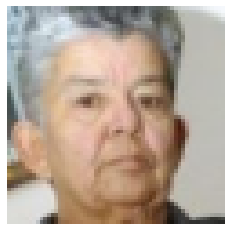

Ari_Fleischer 802 0.45841134


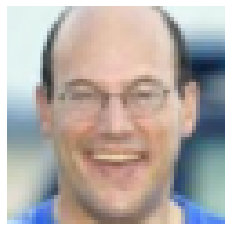

Andre_Agassi 553 0.45511743


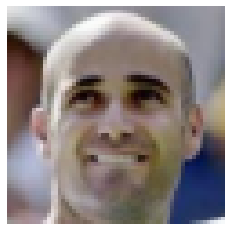

Ben_Howland 1126 0.4547538


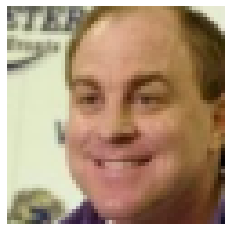

Andrzej_Tyszkiewicz 606 0.45418215


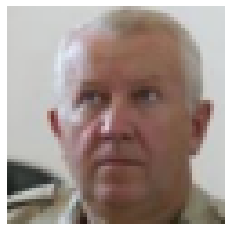

Abdullah_Gul 35 0.45379668


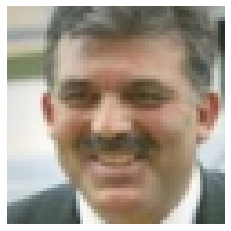

None 1159 0.4535214


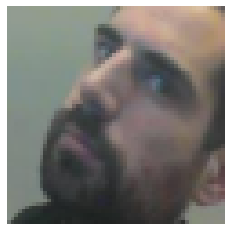

In [181]:
image = camera_grab(camera_id=0,fallback_filename='Files/test_images/olivier/img_olivier_0.jpeg')
x = resize100(image)
out = shared_conv.predict(np.reshape(x, (1, 60, 60, 3)))

print("query image:")
display(x)
for id, sim in most_sim(out[0], emb, topn=10):
    class_name = classid_to_name.get(id_to_classid.get(id))
    print(class_name, id, sim)
    display(all_imgs[id])

# **PART II: Face Verification Using Triplet Loss** #

# Step 1: Processing the Dataset

In [182]:
dirs = sorted(os.listdir(LFW_FOLDER))
dirs = dirs[:500]

name_to_classid = {d:i for i,d in enumerate(dirs)}
classid_to_name = {v:k for k,v in name_to_classid.items()}

num_classes = len(name_to_classid)
print("number of classes: "+str(num_classes))

number of classes: 500


In [183]:
img_paths = {c: [op.join(LFW_FOLDER, subfolder, img) 
                 for img in sorted(os.listdir(op.join(LFW_FOLDER, subfolder)))] 
             for subfolder, c in name_to_classid.items()}

all_images_path = []
for img_list in img_paths.values():
    all_images_path += img_list

path_to_id = {v:k for k,v in enumerate(all_images_path)}
id_to_path = {v:k for k,v in path_to_id.items()}

classid_to_ids = {k:[path_to_id[path] for path in v] for k,v in img_paths.items()}
id_to_classid = {v:c for c,imgs in classid_to_ids.items() for v in imgs}

In [184]:
def resize100(img):
    return resize(img, (100, 100), preserve_range=True, mode='reflect')[20:80,20:80,:]


def open_all_images(id_to_path):
    all_imgs = []
    for path in id_to_path.values():
        all_imgs += [np.expand_dims(resize100(imread(path)),0)]
    return np.vstack(all_imgs)

In [185]:
all_imgs = open_all_images(id_to_path)
mean = np.mean(all_imgs, axis=(0,1,2))
all_imgs -= mean
all_imgs.shape, str(all_imgs.nbytes / 1e6) + "Mo"

((1155, 60, 60, 3), '99.792Mo')

# Step 2: Triplet Loss

In the triplet loss model, we'll define 3 inputs $(a,+,-)$ for anchor, positive and negative.

#### Usage and differences with siamese nets

We release the hard constraint that all data of the same class should be squashed to a single point. Rather, images representation can live on a manifold, as long as they are closer to similar class images than to different class images

On large datasets, with careful hyperparameters, triplets and more advances metric learning method beat siamese nets

#### Outline

We will build positive pairs, and find a way to sample negatives to obtain triplets
Note that we don't need outputs anymore (positive vs negative), we're just building triplets

In [186]:
def build_pos_pairs_for_id(classid, max_num=50):
    imgs = classid_to_ids[classid]
    if len(imgs) == 1:
        return []
    pos_pairs = [(imgs[i], imgs[j]) for i in range(len(imgs)) for j in range(i+1,len(imgs))]
    random.shuffle(pos_pairs)
    return pos_pairs[:max_num]


def build_positive_pairs(class_id_range):
    listX1 = []
    listX2 = []
    
    for class_id in class_id_range:
        pos = build_pos_pairs_for_id(class_id)
        for pair in pos:
            listX1 += [pair[0]]
            listX2 += [pair[1]]
    perm = np.random.permutation(len(listX1))
    return np.array(listX1)[perm], np.array(listX2)[perm]

In [187]:
split_num = int(num_classes * 0.8)

Xa_train, Xp_train = build_positive_pairs(range(0, split_num))
Xa_test, Xp_test = build_positive_pairs(range(split_num, num_classes-1))

all_img_train_idx = list(set(Xa_train) | set(Xp_train))
all_img_test_idx = list(set(Xa_test) | set(Xp_test))

Xa_train.shape, Xp_train.shape

((1177,), (1177,))

In [188]:
# horizontally flip 50% of the images
seq = iaa.Sequential([iaa.Fliplr(0.5)])

In [189]:
class TripletGenerator():
    def __init__(self, Xa_train, Xp_train, batch_size, all_imgs, neg_imgs_idx):
        self.cur_img_index = 0
        self.cur_img_pos_index = 0
        self.batch_size = batch_size
        
        self.imgs = all_imgs
        self.Xa = Xa_train
        self.Xp = Xp_train
        self.cur_train_index = 0
        self.num_samples = Xa_train.shape[0]
        self.neg_imgs_idx = neg_imgs_idx
        
    def next_train(self):
        while 1:
            self.cur_train_index += self.batch_size
            if self.cur_train_index >= self.num_samples:
                self.cur_train_index = 0
            
            imgs_a = self.Xa[self.cur_train_index:self.cur_train_index+self.batch_size]
            imgs_p = self.Xp[self.cur_train_index:self.cur_train_index+self.batch_size]
            
            # THE FIX: Use random.choices to allow re-using images if the pool is small
            imgs_n = random.choices(self.neg_imgs_idx, k=imgs_a.shape[0])
            
            yield ([seq.augment_images(self.imgs[imgs_a]), 
                    seq.augment_images(self.imgs[imgs_p]),
                    seq.augment_images(self.imgs[imgs_n])
                    ],
                    np.zeros(shape=(imgs_a.shape[0])) # Dummy target for Keras
                )

In [190]:
batch_size = 128

gen = TripletGenerator(Xa_train, Xp_train, batch_size, all_imgs, all_img_train_idx)
gen_test = TripletGenerator(Xa_test, Xp_test, batch_size, all_imgs, all_img_test_idx)

[xa, xp, xn], y = next(gen.next_train())

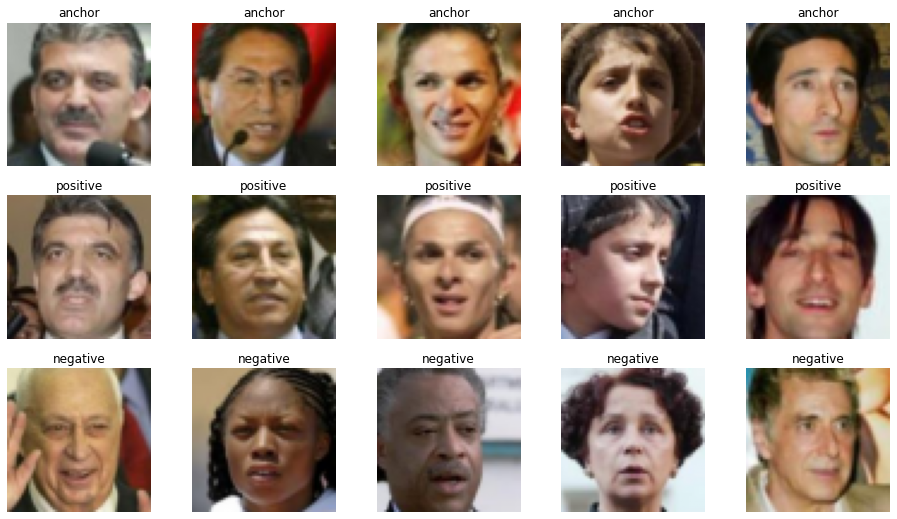

In [191]:
plt.figure(figsize=(16, 9))

for i in range(5):
    plt.subplot(3, 5, i + 1)
    plt.title("anchor")
    plt.imshow((xa[i] + mean) / 255)
    plt.axis('off')
for i in range(5):
    plt.subplot(3, 5, i + 6)
    plt.title("positive")
    plt.imshow((xp[i] + mean) / 255)
    plt.axis('off')
for i in range(5):
    plt.subplot(3, 5, i + 11)
    plt.title("negative")
    plt.imshow((xn[i] + mean) / 255)
    plt.axis('off')

plt.show()

# Step 3: Triplet Model

The loss of the triplet model is as follows:

$$ max(0, ||x_a - x_p||\_2 - ||x_a - x_n||\_2 + \alpha)$$

We'll be using cosine similarities instead of euclidean distances (seems to be working a bit better in that case), so the loss becomes:

$$ max(0, cos(x_a, x_n) - cos(x_a - x_p) + \alpha)$$

In [192]:
def identity_loss(y_true, y_pred):
    return K.mean(y_pred - 0 * y_true)


def cosine_triplet_loss(X):
    _alpha = 0.5
    positive_sim, negative_sim = X
    losses = K.maximum(0.0, negative_sim - positive_sim + _alpha)
    
    return K.mean(losses)

In [193]:
inp = Input((60,60,3), dtype='float32')

x = Conv2D(16, 3, activation="relu", padding="same")(inp)
x = Conv2D(16, 3, activation="relu", padding="same")(x)
x = MaxPool2D((2,2))(x) # 30,30
x = Conv2D(32, 3, activation="relu", padding="same")(x)
x = Conv2D(32, 3, activation="relu", padding="same")(x)
x = MaxPool2D((2,2))(x) # 15,15
x = Conv2D(64, 3, activation="relu", padding="same")(x)
x = Conv2D(64, 3, activation="relu", padding="same")(x)
x = MaxPool2D((2,2))(x) # 8,8
x = Conv2D(64, 3, activation="relu", padding="same")(x)
x = Conv2D(32, 3, activation="relu", padding="same")(x)
x = Flatten()(x)
x = Dropout(0.2)(x)
x = Dense(40, activation="tanh")(x)
x = Dropout(0.2)(x)
x = Dense(64)(x)

shared_conv2 = Model(inputs=inp, outputs = x)

**Exercise**

- Build the triplet model, using the skeleton below
- First run the 3 inputs through the shared conv
- Then compute positive and negative similarities
- Then call the triplet loss function using a `Lambda` layer
- There are other ways to do it, however Keras API is not perfect for triplets

In [194]:
def triplet_loss(inputs):
    pos_sim, neg_sim = inputs
    margin = 0.2
    
    return K.maximum(neg_sim - pos_sim + margin, 0.0)


def identity_loss(y_true, y_pred):
    return K.mean(y_pred)

In [195]:
anchor = Input((60, 60, 3), name='anchor')
positive = Input((60, 60, 3), name='positive')
negative = Input((60, 60, 3), name='negative')

# 1. Run the 3 inputs through the exact same network (shared_conv2)
emb_a = shared_conv2(anchor)
emb_p = shared_conv2(positive)
emb_n = shared_conv2(negative)

# 2. Compute similarities using the Dot layer
pos_sim = Dot(axes=-1, normalize=True)([emb_a, emb_p])
neg_sim = Dot(axes=-1, normalize=True)([emb_a, emb_n])

# 3. Call the triplet loss function using a Lambda layer
loss = Lambda(triplet_loss)([pos_sim, neg_sim])

# 4. Build the final model
model_triplet = Model(
    inputs=[anchor, positive, negative],
    outputs=loss
)

# 5. Compile the model
model_triplet.compile(loss=identity_loss, optimizer="rmsprop")

In [196]:
a = shared_conv2(anchor)
p = shared_conv2(positive)
n = shared_conv2(negative)

pos_sim = Dot(axes=-1, normalize=True)([a,p])
neg_sim = Dot(axes=-1, normalize=True)([a,n])

loss = Lambda(cosine_triplet_loss, output_shape=(1,))([pos_sim,neg_sim])

model_triplet = Model(inputs=[anchor, positive, negative], outputs=loss)
model_triplet.compile(loss=identity_loss, optimizer="rmsprop")

In [197]:
best_model_fname = "Files/triplet_checkpoint_b2.h5"
best_model_cb = ModelCheckpoint(best_model_fname, monitor='val_loss', save_best_only=True, verbose=1)

In [198]:
history = model_triplet.fit_generator(
    generator=gen.next_train(), 
    steps_per_epoch=Xa_train.shape[0] // batch_size, 
    epochs=3,
    validation_data=gen_test.next_train(),
    validation_steps=Xa_test.shape[0] // batch_size,
    callbacks=[best_model_cb]
)

Epoch 1/3
9/9 [==============================] - 11s 1s/step - loss: 0.4985 - val_loss: 0.5000

Epoch 00001: val_loss improved from inf to 0.50000, saving model to Files/triplet_checkpoint_b2.h5
Epoch 2/3
9/9 [==============================] - 10s 1s/step - loss: 0.5002 - val_loss: 0.5000

Epoch 00002: val_loss did not improve from 0.50000
Epoch 3/3
9/9 [==============================] - 11s 1s/step - loss: 0.4965 - val_loss: 0.5000

Epoch 00003: val_loss did not improve from 0.50000


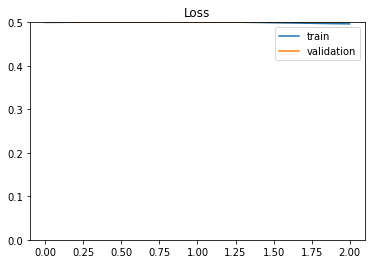

In [199]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.ylim(0, 0.5)
plt.legend(loc='best')
plt.title('Loss');

# Step 4: Displaying Similar Images

In [200]:
model_triplet.load_weights(TRIPLET_PRE_FILE)

emb = shared_conv2.predict(all_imgs)
emb = emb / np.linalg.norm(emb, axis=-1, keepdims=True)

In [201]:
def euclidean(idx1,idx2):
    return np.linalg.norm(emb[idx1] - emb[idx2])


def cosine(idx1, idx2):
    return np.dot(emb[idx1], emb[idx2])


def most_sim(x, emb, topn=5, mode="cosine"):
    if mode == "cosine":
        x = x / np.linalg.norm(x)
        sims = np.dot(emb, x)
        ids = np.argsort(sims)[::-1]
        return [(id,sims[id]) for id in ids[:topn]]
    else:
        dists = np.linalg.norm(emb - x, axis=-1)
        ids = np.argsort(dists)
        return [(id,dists[id]) for id in ids[:topn]]
    
    
def display(img):
    img = img.astype('uint8')
    plt.imshow(img)
    plt.axis('off')
    plt.show()

67


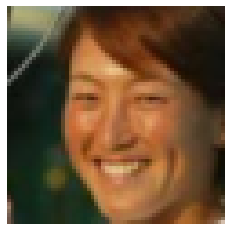

('Ai_Sugiyama', 132, 1.0)


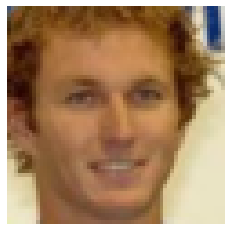

('Aaron_Peirsol', 6, 0.96959525)


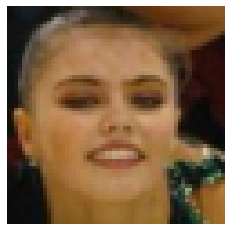

('Alina_Kabaeva', 375, 0.9582168)


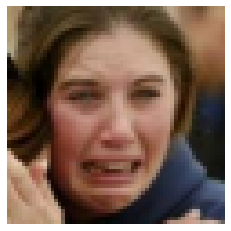

('Amy_Gale', 497, 0.9460214)


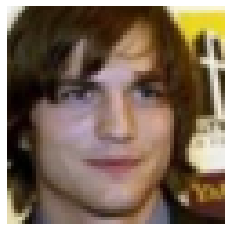

('Ashton_Kutcher', 996, 0.94460005)


In [202]:
interesting_classes = list(filter(lambda x: len(x[1])>4, classid_to_ids.items()))
class_idx = random.choice(interesting_classes)[0]
print(class_idx)

img_idx = random.choice(classid_to_ids[class_idx])
for id, sim in most_sim(emb[img_idx], emb):
    display(all_imgs[id] + mean)
    print((classid_to_name[id_to_classid[id]], id, sim))

# Step 5: Test Recall@k model

In [203]:
test_ids = []
for class_id in range(split_num, num_classes-1):
    img_ids = classid_to_ids[class_id]
    if len(img_ids) > 1:
        test_ids += img_ids
        

print(len(test_ids))
len([len(classid_to_ids[x]) for x in list(range(split_num, num_classes-1)) if len(classid_to_ids[x])>1])

93


22

In [204]:
def recall_k(k=10):
    num_found = 0
    for img_idx in test_ids:
        image_class = id_to_classid[img_idx]
        found_classes = [id_to_classid[x] for (x, score) in most_sim(emb[img_idx], emb, topn=k+1)[1:]]
        if image_class in found_classes:
            num_found += 1
    return num_found / len(test_ids)


def random_recall_k(k=10):
    num_found = 0
    for img_idx in test_ids:
        image_class = id_to_classid[img_idx]
        found_classes = [id_to_classid[x] for x in random.sample(list(set(test_ids) - {img_idx}), k)]
        #found_classes = [id_to_classid[x] for (x, score) in most_sim(norm_emb[img_idx], norm_emb, topn=k+1)[1:]]
        if image_class in found_classes:
            num_found += 1
    return num_found / len(test_ids)

In [205]:
recall_k(k=10)
random_recall_k(k=10)

0.3978494623655914

# Step 6: Hard Negative Mining

In [206]:
def build_similarities(conv, all_imgs):
    embs = conv.predict(all_imgs)
    embs = embs / np.linalg.norm(embs, axis=-1, keepdims=True)
    all_sims = np.dot(embs, embs.T)
    return all_sims


def intersect(a, b):
    return list(set(a) & set(b))


def build_negatives(anc_idxs, pos_idxs, similarities, neg_imgs_idx, num_retries=20):
    if similarities is None:
        return random.sample(neg_imgs_idx,len(anc_idxs))
    
    final_neg = []
    for (anc_idx, pos_idx) in zip(anc_idxs, pos_idxs):
        anchor_class = id_to_classid[anc_idx]
        
        #positive similarity
        sim = similarities[anc_idx, pos_idx]
        
        # find all negatives which are semi(hard)
        possible_ids = np.where((similarities[anc_idx] + 0.25) > sim)[0]
        possible_ids = intersect(neg_imgs_idx, possible_ids)
        appended = False
        for iteration in range(num_retries):
            if len(possible_ids) == 0:
                break
            idx_neg = random.choice(possible_ids)
            if id_to_classid[idx_neg] != anchor_class:
                final_neg.append(idx_neg)
                appended = True
                break
        if not appended:
            final_neg.append(random.choice(neg_imgs_idx))
    return final_neg


class HardTripletGenerator():
    def __init__(self, Xa_train, Xp_train, batch_size, all_imgs, neg_imgs_idx, conv):
        self.cur_img_index=0
        self.cur_img_pos_index=0
        self.batch_size = batch_size
        
        self.imgs = all_imgs
        self.Xa = Xa_train
        self.Xp = Xp_train
        self.cur_train_index = 0
        self.num_samples = Xa_train.shape[0]
        self.neg_imgs_idx = neg_imgs_idx
        self.all_anchors = list(set(Xa_train))
        self.mapping_pos = {v:k for k,v in enumerate(self.all_anchors)}
        self.mapping_neg = {k:v for k,v in enumerate(self.neg_imgs_idx)}
        if conv:
            self.similarities = build_similarities(conv, self.imgs)
        else:
            self.similarities = None
        
    def next_train(self):
        while 1:
            self.cur_train_index += self.batch_size
            if self.cur_train_index >= self.num_samples:
                self.cur_train_index=0
            
            imgs_a = self.Xa[self.cur_train_index:self.cur_train_index+self.batch_size]
            imgs_p = self.Xp[self.cur_train_index:self.cur_train_index+self.batch_size]
            imgs_n = build_negatives(imgs_a, imgs_p, self.similarities, self.neg_imgs_idx)
        
            yield ([seq.augment_images(self.imgs[imgs_a]), 
                    seq.augment_images(self.imgs[imgs_p]),
                    seq.augment_images(self.imgs[imgs_n])
                    ],
                    np.zeros(shape=(imgs_a.shape[0]))
                )

In [207]:
batch_size = 128
gen_hard = HardTripletGenerator(Xa_train, Xp_train, batch_size, all_imgs, all_img_train_idx, shared_conv2)
len(all_img_train_idx)

678

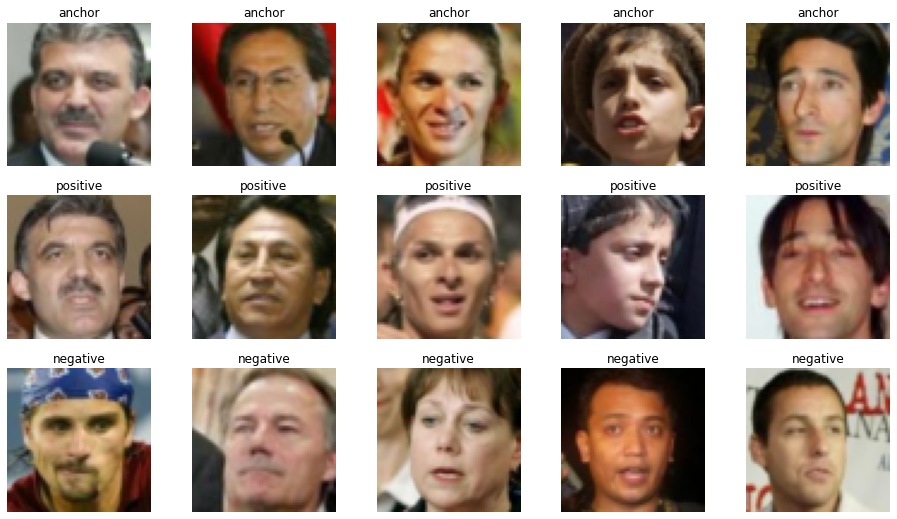

In [208]:
[xa, xp, xn], y = next(gen_hard.next_train())

plt.figure(figsize=(16, 9))

for i in range(5):
    plt.subplot(3, 5, i + 1)
    plt.title("anchor")
    plt.imshow((xa[i] + mean) / 255)
    plt.axis('off')
for i in range(5):
    plt.subplot(3, 5, i + 6)
    plt.title("positive")
    plt.imshow((xp[i] + mean) / 255)
    plt.axis('off')
for i in range(5):
    plt.subplot(3, 5, i + 11)
    plt.title("negative")
    plt.imshow((xn[i] + mean) / 255)
    plt.axis('off')

plt.show()

In [209]:
inp = Input((60,60,3), dtype='float32')

x = Conv2D(16, 3, activation="relu", padding="same")(inp)
x = Conv2D(16, 3, activation="relu", padding="same")(x)
x = MaxPool2D((2,2))(x) # 30,30
x = Conv2D(32, 3, activation="relu", padding="same")(x)
x = Conv2D(32, 3, activation="relu", padding="same")(x)
x = MaxPool2D((2,2))(x) # 15,15
x = Conv2D(64, 3, activation="relu", padding="same")(x)
x = Conv2D(64, 3, activation="relu", padding="same")(x)
x = MaxPool2D((2,2))(x) # 8,8
x = Conv2D(64, 3, activation="relu", padding="same")(x)
x = Conv2D(32, 3, activation="relu", padding="same")(x)
x = Flatten()(x)
x = Dropout(0.2)(x)
x = Dense(50, activation="tanh")(x)
x = Dense(50)(x)

shared_conv2 = Model(inputs=inp, outputs = x)

In [210]:
anchor = Input((60, 60, 3), name='anchor')
positive = Input((60, 60, 3), name='positive')
negative = Input((60, 60, 3), name='negative')

a = shared_conv2(anchor)
p = shared_conv2(positive)
n = shared_conv2(negative)

pos_sim = Dot(axes=-1, normalize=True)([a,p])
neg_sim = Dot(axes=-1, normalize=True)([a,n])

loss = Lambda(cosine_triplet_loss,output_shape=(1,))([pos_sim,neg_sim])
model_triplet = Model(inputs=[anchor, positive, negative],outputs=loss)
opt = optimizers.SGD(lr=0.001, decay=1e-6, momentum=0.9, nesterov=True)
model_triplet.compile(loss=identity_loss, optimizer=opt)

In [211]:
gen_test = TripletGenerator(Xa_test, Xp_test, batch_size, all_imgs, all_img_test_idx)
gen_hard = HardTripletGenerator(Xa_train, Xp_train, batch_size, all_imgs, all_img_train_idx, None)

In [212]:
nb_epochs = 5
for epoch in range(nb_epochs):
    print("built new hard generator for epoch "+str(epoch))
    model_triplet.fit_generator(generator=gen_hard.next_train(), 
                    steps_per_epoch=Xa_train.shape[0] // batch_size, 
                    epochs=1,
                    validation_data = gen_test.next_train(),
                    validation_steps=Xa_test.shape[0] // batch_size)
    gen_hard = HardTripletGenerator(Xa_train, Xp_train, batch_size, all_imgs, all_img_train_idx, shared_conv2)

built new hard generator for epoch 0
Epoch 1/1
9/9 [==============================] - 11s 1s/step - loss: 0.4909 - val_loss: 0.4037
built new hard generator for epoch 1
Epoch 1/1
9/9 [==============================] - 11s 1s/step - loss: 0.5015 - val_loss: 0.3431
built new hard generator for epoch 2
Epoch 1/1
9/9 [==============================] - 11s 1s/step - loss: 0.4778 - val_loss: 0.4148
built new hard generator for epoch 3
Epoch 1/1
9/9 [==============================] - 11s 1s/step - loss: 0.4778 - val_loss: 0.4275
built new hard generator for epoch 4
Epoch 1/1
9/9 [==============================] - 11s 1s/step - loss: 0.4781 - val_loss: 0.4270
built new hard generator for epoch 5
Epoch 1/1
9/9 [==============================] - 10s 1s/step - loss: 0.4608 - val_loss: 0.3759
built new hard generator for epoch 6
Epoch 1/1
9/9 [==============================] - 10s 1s/step - loss: 0.4807 - val_loss: 0.4071
built new hard generator for epoch 7
Epoch 1/1
9/9 [========================

In [ ]:
emb = shared_conv2.predict(all_imgs)
emb = emb / np.linalg.norm(emb, axis=-1, keepdims=True)

recall_k(k=10)
random_recall_k(k=10)

0.43010752688172044